In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error

In [2]:
sdss_path = "sdss.csv"
df = pd.read_csv(sdss_path)


In [3]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118070 entries, 0 to 118069
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   objid      118070 non-null  float64
 1   ra         118070 non-null  float64
 2   dec        118070 non-null  float64
 3   u          118070 non-null  float64
 4   g          118070 non-null  float64
 5   r          118070 non-null  float64
 6   i          118070 non-null  float64
 7   z          118070 non-null  float64
 8   run        118070 non-null  int64  
 9   rerun      118070 non-null  int64  
 10  camcol     118070 non-null  int64  
 11  field      118070 non-null  int64  
 12  specobjid  118070 non-null  float64
 13  class      118070 non-null  object 
 14  redshift   118070 non-null  float64
 15  plate      118070 non-null  int64  
 16  mjd        118070 non-null  int64  
 17  fiberid    118070 non-null  int64  
dtypes: float64(10), int64(7), object(1)
memory usage: 16.2+ MB


,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [4]:
features = ['u', 'g', 'r', 'i', 'z']


## Performing regression and classificaiton tasks 

Regression will predict redshift
Classification will predict object type

In [5]:
task = "classification"

In [6]:
if task == "classification":
    # convert class labels to numeric values
    df['class'] = df['class'].map({'STAR': 0, 'GALAXY': 1, 'QSO': 2})
    df = df.dropna(subset=['class'])  # drops missing labels
    target = 'class'
    model = RandomForestClassifier(n_estimators=100, random_state=42)
elif task == "regression":
    df = df.dropna(subset=['redshift'])  # srop missing labels
    target = 'redshift'
    model = RandomForestRegressor(n_estimators=100, random_state=42)


In [7]:
X = df[features]
y = df[target]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred = model.predict(X_test)

In [11]:
if task == "classification":
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
elif task == "regression":
    print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))


Accuracy: 0.8927331244177183
              precision    recall  f1-score   support

           0       0.86      0.81      0.84      5644
           1       0.93      0.96      0.94     14442
           2       0.79      0.77      0.78      3528

    accuracy                           0.89     23614
   macro avg       0.86      0.84      0.85     23614
weighted avg       0.89      0.89      0.89     23614



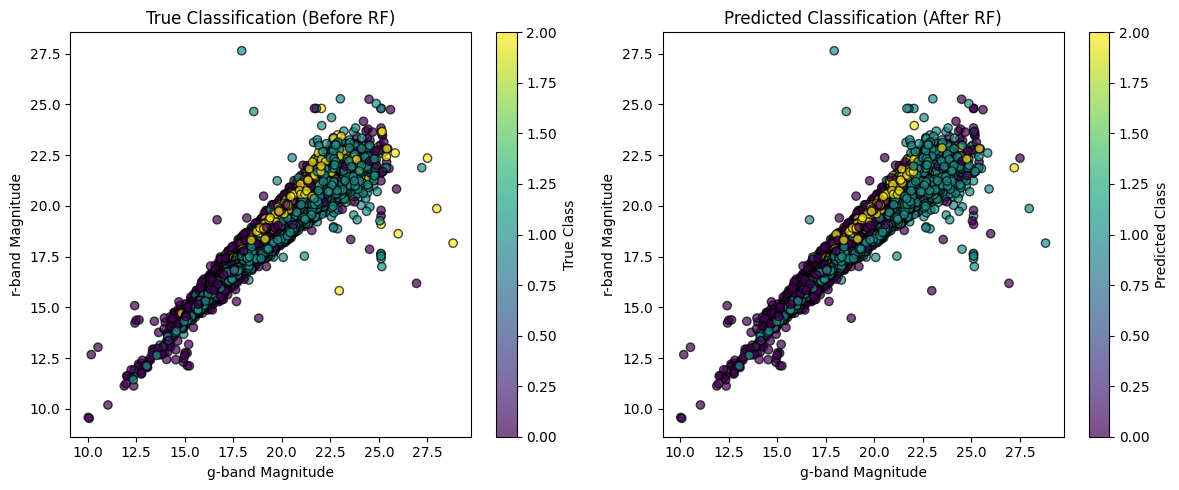

In [13]:
import matplotlib.pyplot as plt

# Scatter plot before classification (true labels)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_test["g"], X_test["r"], c=y_test, cmap="viridis", edgecolor='k', alpha=0.7)
plt.colorbar(label="True Class")
plt.xlabel("g-band Magnitude")
plt.ylabel("r-band Magnitude")
plt.title("True Classification (Before RF)")

# Scatter plot after classification (RF predicted labels)
plt.subplot(1, 2, 2)
plt.scatter(X_test["g"], X_test["r"], c=y_pred, cmap="viridis", edgecolor='k', alpha=0.7)
plt.colorbar(label="Predicted Class")
plt.xlabel("g-band Magnitude")
plt.ylabel("r-band Magnitude")
plt.title("Predicted Classification (After RF)")

plt.tight_layout()
plt.show()



### Confusion matrix for predicted classification from features/class:


- 0- star
- 1- galaxy
- 2- quasar

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [20]:
cm=confusion_matrix(y_test,y_pred)

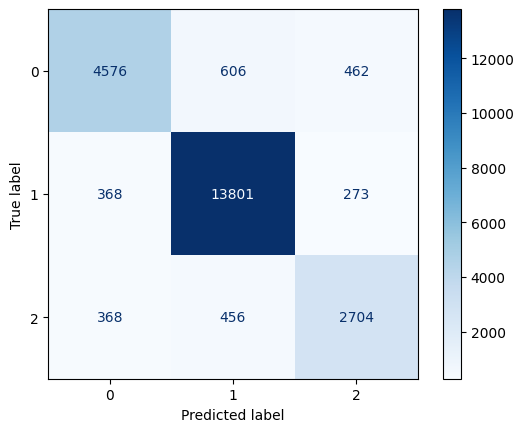

In [21]:
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.show()

### Conclusions:
1. The above model performed with 89% accuracy. 
2. Highest precision was recorded in classifying galaxies with 94% accuracy. In the confusion matrix it can be seen that 13801 galaxies were classfied correctly.
3. the confusion matrix diagonal has the deepest values showing high accuracy results.
4. Quasars ahve the highest misclassification

### Increasing accuracy

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [33]:
param_dist = {
    'n_estimators': [50, 100, 300],  # Smaller range for efficiency
    'max_depth': [10, 20],  # Prevent deep trees for faster results
    'min_samples_split': [2, 5, 10],  # Control overfitting
    'min_samples_leaf': [1, 2, 4]  # Keep best minimum leaf options
}

In [34]:
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  # Test only 20 random combinations instead of all 54
    cv=2,  # Faster cross-validation
    n_jobs=-1,  # Use all CPU cores
    verbose=2,
    random_state=42  # Ensures reproducibility
)

In [35]:
random_search.fit(X_train, y_train)

Fitting 2 folds for each of 20 candidates, totalling 40 fits


RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 300]},
                   random_state=42, verbose=2)

In [36]:
print("Best Parameters:", random_search.best_params_)

Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


### Retraining model:

Model is being retrained by the above parametres and will be compared with previous performance.

In [37]:
from sklearn.ensemble import RandomForestClassifier

# Best parameters from tuning
best_params = {'n_estimators': 300, 
               'min_samples_split': 5, 
               'min_samples_leaf': 1, 
               'max_depth': 20}

# Train the final model on the full training data
final_model = RandomForestClassifier(**best_params, random_state=42)
final_model.fit(X_train, y_train)

print("Final model trained with best hyperparameters.")


Final model trained with best hyperparameters.


In [38]:
from sklearn.metrics import accuracy_score, classification_report

# Predict on the test set
y_pred = final_model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Final Model Accuracy: {accuracy:.4f}")

# Print classification report for precision, recall, F1-score
print("Classification Report:")
print(classification_report(y_test, y_pred))


Final Model Accuracy: 0.8910
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      5644
           1       0.92      0.96      0.94     14442
           2       0.79      0.77      0.78      3528

    accuracy                           0.89     23614
   macro avg       0.86      0.84      0.85     23614
weighted avg       0.89      0.89      0.89     23614

